# Part 1. Sequence Manipulation & Biological Operations

In [2]:
from Bio.Seq import Seq

dna_seq = 'ATGGCTTCACCGAATGGATAA'

dna_seq = Seq(dna_seq).upper()

complement_seq = dna_seq.complement()
reverse_comp_seq = dna_seq.reverse_complement()
rna_seq = dna_seq.transcribe()
translated_pr = rna_seq.translate(cds=True, to_stop=True)

print(f'{complement_seq}\n{reverse_comp_seq}\n{rna_seq}\n{translated_pr}')
# We can also use Seq.complement(dna_seq)
# exp: coding_sequence = record.Seq.reverse_complement()

TACCGAAGTGGCTTACCTATT
TTATCCATTCGGTGAAGCCAT
AUGGCUUCACCGAAUGGAUAA
MASPNG


# Part 2. Sequence Records & File I/O

In [3]:
from Bio import SeqIO

records = SeqIO.parse('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta',
                      format='fasta')

for rec in records:
        print(rec.id)

NM_006996.3
NM_004006.3


In [4]:
record_1 = next(SeqIO.parse('/mnt/d/Bioinformatics/Seq Records & Files/temp_seq_list.fasta',
                      format='fasta'))

print('Record 1 Sequence:', record_1.seq)

Record 1 Sequence: AGAGGCGTCTGTAGGGTAAAGCTGGGGGTTCTGTAGCCGGAGGCGGCGGCGAGTCCAGAACGTCCTGGCCTTACAGGGAGAAGGCGTCACTCGCGGTTACAAGTGCCTGACCCTCACTCCAGTTGGCGGAGGAGGAGAAGGAAGGGGCCGGGCCGGGTCCCCTCCCCTCGCGCCCCGGATGGATGTGCCCGGCCCGGTGTCTCGGCGGGCGGCGGCGGCGGCGGCCACTGTGCTCCTGCGGACCGCTCGGGTCCGTCGCGAATGCTGGTTCTTGCCGACCGCGCTGCTCTGCGCCTACGGCTTCTTCGCCAGCCTCAGGCCGTCCGAGCCCTTCCTGACCCCGTACCTGCTGGGGCCGGACAAGAACCTGACCGAGAGGGAGGTCTTCAATGAAATTTATCCAGTATGGACTTACTCTTACCTGGTGCTACTGTTTCCTGTGTTCCTTGCCACAGACTACCTCCGTTATAAACCTGTTGTTCTACTGCAGGGGCTCAGCCTTATTGTTACATGGTTTATGCTGCTCTATGCCCAGGGACTGCTGGCCATTCAATTTCTAGAATTTTTTTATGGCATCGCCACAGCCACTGAAATTGCCTATTACTCTTATATCTACAGTGTGGTGGACCTGGGCATGTACCAGAAAGTCACAAGTTACTGTCGAAGTGCCACTTTGGTGGGCTTTACAGTGGGCTCTGTCCTAGGGCAAATCCTTGTCTCAGTGGCAGGCTGGTCGCTGTTCAGCCTGAATGTCATCTCTCTTACCTGTGTTTCAGTGGCTTTTGCTGTGGCCTGGTTTTTACCTATGCCACAGAAGAGCCTCTTCTTTCACCACATTCCTTCTACCTGCCAGAGAGTGAATGGCATCAAGGTACAAAATGGTGGCATTGTTACTGACACCCCAGCTTCTAACCACCTTCCTGGCTGGGAGGACATTGAGTCAAAAATCCCTCTAAATATGGAGGAGCCTCCCGTGGAGGA

In [5]:
SeqIO.write(record_1,
            '/mnt/d/Bioinformatics/Seq Records & Files/temp_record_1.fasta',
            format='fasta')

1

# 3. Pairwise Sequence Alignment

In [6]:
from Bio import Align

seq_1 = 'AAACTACGGC'
seq_2 = 'AACCTAAGA'

aligner = Align.PairwiseAligner() # Engine

aligner.mode = 'global'
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = 0.5
aligner.extend_gap_score = -0.1

alignments = aligner.align(seq_1, seq_2)

print(print(f'{alignments[0]}\nAlignment Score: {alignments.score}'))

target            0 AA-ACTAC-GG-C 10
                  0 ||--|||---|-- 13
query             0 AAC-CTA-A-GA-  9

Alignment Score: 15.5
None


In [7]:
# Unlike DNA nucleotides, amino acids are not equally dissimilar and may share physicochemical properties; 
# Substitution matrices such as BLOSUM and PAM matrices account for these differences in protein sequence alignment and modeling.
# For example, in BLOSUM62, each possible pair of amino acids is assigned a substitution score.
from Bio.Align import substitution_matrices

aligner.substitution_matrix = substitution_matrices.load('BLOSUM62')

aa_alignments = aligner.align('APID', 'APLDR')

for alignment in aa_alignments:
    print(f'{alignment}\n\n{alignment.score}')

target            0 APID- 4
                  0 ||.|- 5
query             0 APLDR 5


19.5


# 4. Motifs → PWM → PSSM

In [8]:
# motif → counts matrix → normalize → PWM → log-odds → PSSM
# A recurring nucleotide sequence pattern is called a motif.
# A motif is not necessarily an exact sequence; 
# rather, it can represent a probabilistic pattern in which different nucleotides have different probabilities at each position.
from Bio import motifs

sequences = [
    "ATGCAA",
    "ATGCTA",
    "AAGCAA",
    "ATGCCA"
]

motif = motifs.create(sequences) # making the count matrix

pwm = motif.counts.normalize(pseudocounts=0.1) # making pwm by normalizing the counts matrix

pssm = pwm.log_odds() # making PSSM by getting log_odds from the PWM

print(pssm)

        0      1      2      3      4      5
A:   1.90   0.00  -3.46  -3.46   0.93   1.90
C:  -3.46  -3.46  -3.46   1.90   0.00  -3.46
G:  -3.46  -3.46   1.90  -3.46  -3.46  -3.46
T:  -3.46   1.49  -3.46  -3.46   0.00  -3.46



# 5. MSA & Phylogenetics

In [ ]:
# Before constructing the phylogenetic tree, seqs should be subjeted to MSA
# Biopython does not verify whether the sequences provided to `MultipleSeqAlignment` are correctly aligned;
# and this does not mean that Biopython performed the alignment; it simply treats the provided sequences as an alignment.

# Note: We can use "Clustal Omega" to do MSA
from Bio import AlignIO
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment

seqs = ['ATGCTA',
        'ATGCAA',
        'ATCCAA',
        'TTCCAA']

seq_records = []
for i, seq in enumerate(seqs, start=1):
    seq_records.append(SeqRecord(Seq(seq), id=f'seq_{i}'))
    
alignments = MultipleSeqAlignment(records=seq_records)

AlignIO.write(alignments,
              '/mnt/d/Bioinformatics/Seq Records & Files/alignments.phy',
              'phylip')

alignments = AlignIO.read('/mnt/d/Bioinformatics/Seq Records & Files/alignments.phy', 'phylip')

In [ ]:
# MSA -> Distance Matrix -> Phylogenetic Tree
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

d_calc = DistanceCalculator('identity')

distance_matrix = d_calc.get_distance(alignments)

constructor = DistanceTreeConstructor()

phylo_tree = constructor.upgma(distance_matrix) # or nj instead of upgma

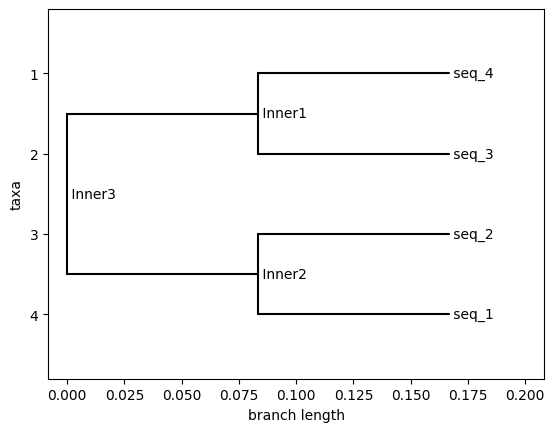

In [ ]:
# Tree Visulization:
from Bio import Phylo

Phylo.draw(phylo_tree)